In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("email_spam_svm.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,word_freq_free,word_freq_money,word_freq_offer,email_length,is_spam
0,5.88,0.15,6.86,341.2,1
1,0.00,5.76,7.33,474.0,1
2,1.97,5.71,0.69,300.7,1
3,7.80,1.53,3.43,195.2,1
4,3.42,4.20,2.36,68.2,1


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (150, 5)

Columns:
Index(['word_freq_free', 'word_freq_money', 'word_freq_offer', 'email_length',
       'is_spam'],
      dtype='str')


In [6]:
print(df.isnull().sum())

word_freq_free     0
word_freq_money    0
word_freq_offer    0
email_length       0
is_spam            0
dtype: int64


In [7]:
# Check spam and not spam count

print(df["is_spam"].value_counts())

is_spam
1    146
0      4
Name: count, dtype: int64


In [8]:
df.describe()

,word_freq_free,word_freq_money,word_freq_offer,email_length,is_spam
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.376133,2.846800,3.844067,301.690000,0.973333
std,2.817702,1.640422,2.202354,128.771808,0.161647
min,0.000000,0.040000,0.030000,51.700000,0.000000
25%,3.210000,1.482500,1.977500,196.525000,1.000000
50%,5.710000,2.725000,3.970000,311.650000,1.000000
75%,7.730000,4.165000,5.460000,413.000000,1.000000
max,9.880000,5.960000,8.000000,498.200000,1.000000


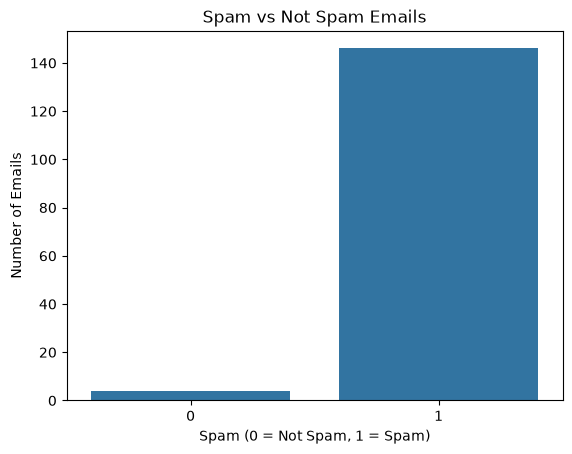

In [9]:
# Plot spam vs not spam

sns.countplot(x="is_spam", data=df)

plt.title("Spam vs Not Spam Emails")
plt.xlabel("Spam (0 = Not Spam, 1 = Spam)")
plt.ylabel("Number of Emails")

plt.show()

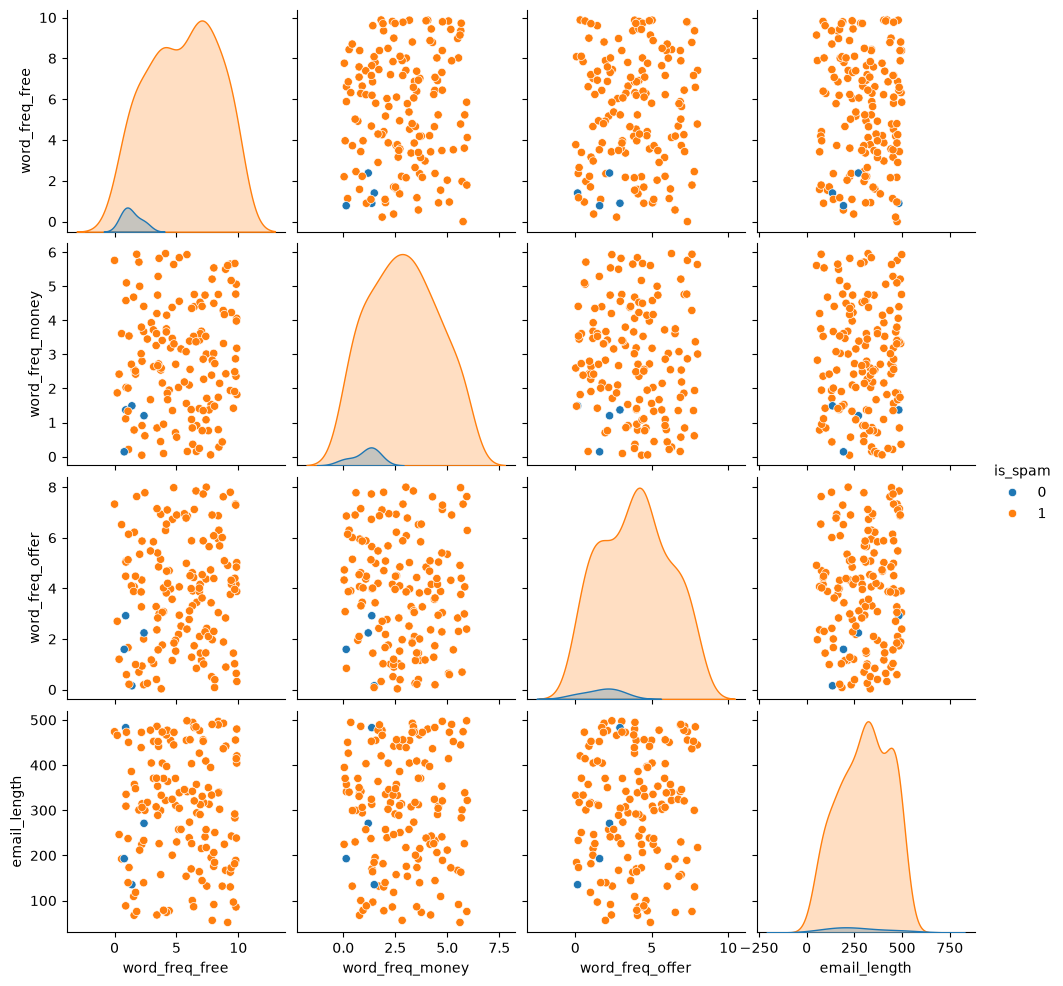

In [10]:
# Visualize feature data points

sns.pairplot(
    df,
    vars=[
        "word_freq_free",
        "word_freq_money",
        "word_freq_offer",
        "email_length"
    ],
    hue="is_spam"
)

plt.show()

In [11]:
# Select features and target

X = df[
    [
        "word_freq_free",
        "word_freq_money",
        "word_freq_offer",
        "email_length"
    ]
]

y = df["is_spam"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [12]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [13]:
# Create SVM model with RBF kernel

model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf")
)

print(model)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svc', SVC())])


In [14]:
# Set up 5-fold cross-validation

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [15]:
# Calculate 5-fold accuracy

from sklearn.model_selection import cross_val_score

accuracy = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Accuracy for each fold:")
print(accuracy)

print("\nMean Accuracy:")
print(accuracy.mean())

Accuracy for each fold:
[1.         0.96666667 0.96666667 0.96666667 0.96666667]

Mean Accuracy:
0.9733333333333334


c:\Users\sharm\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


In [16]:
roc_auc = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("ROC-AUC for each fold:")
print(roc_auc)

print("\nMean ROC-AUC:")
print(roc_auc.mean())

ROC-AUC for each fold:
[       nan 0.93103448 1.         1.         0.96551724]

Mean ROC-AUC:
nan


c:\Users\sharm\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\sharm\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [17]:
# Train SVM on the complete dataset

model.fit(X, y)

print("SVM model trained successfully!")

SVM model trained successfully!


In [18]:
# Create the new email data

new_email = [[2.1, 1.3, 0.7, 180]]

prediction = model.predict(new_email)

print("Prediction:", prediction[0])

Prediction: 1


c:\Users\sharm\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [19]:
if prediction[0] == 1:
    print("The email is predicted as SPAM")
else:
    print("The email is predicted as NOT SPAM")

The email is predicted as SPAM
